#### **My Prediction: I expect the Bilateral Filter to preserve the text edges best. While Gaussian and Mean filters blur edges entirely, and the Median filter can distort delicate stroke geometry, the Bilateral filter incorporates both spatial distance and pixel intensity differences, allowing it to smooth out noise on flat surfaces while preserving sharp edge boundaries.**

#### **IMPORT LIBRARIES**

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import gray

#### **Reading the Image and adding Guassian Noise**

(np.float64(-0.5), np.float64(1199.5), np.float64(1599.5), np.float64(-0.5))

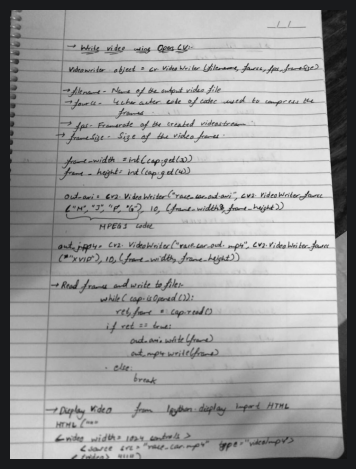

In [13]:
img_txt = cv2.imread("img.jpg", cv2.IMREAD_GRAYSCALE)
org_image = cv2.imread("img.jpg",cv2.IMREAD_GRAYSCALE)

h, w = img_txt.shape[:2]

img_txt = cv2.resize(img_txt, (1000, int(h * (1000 / w))))

#Add Guassian Noise(mean =0, sigma =25)
np.random.seed(42)
noise = np.random.normal(0,25,img_txt.shape).astype(np.float32)
noisy_img = np.clip(img_txt.astype(np.float32) + noise, 0, 255).astype(np.uint8)

#ApplyFilters
blur_mean = cv2.blur(noisy_img, (7,7))
blur_gaussian = cv2.GaussianBlur(noisy_img, (7,7), 0)
blur_median = cv2.medianBlur(noisy_img, 7)
blur_bilateral = cv2.bilateralFilter(noisy_img,7,75,75)

#Showing the original image
plt.figure(figsize=(20,10))
plt.subplot(141);plt.imshow(org_image,cmap="gray");plt.axis('off')

####  **Visualizing results**

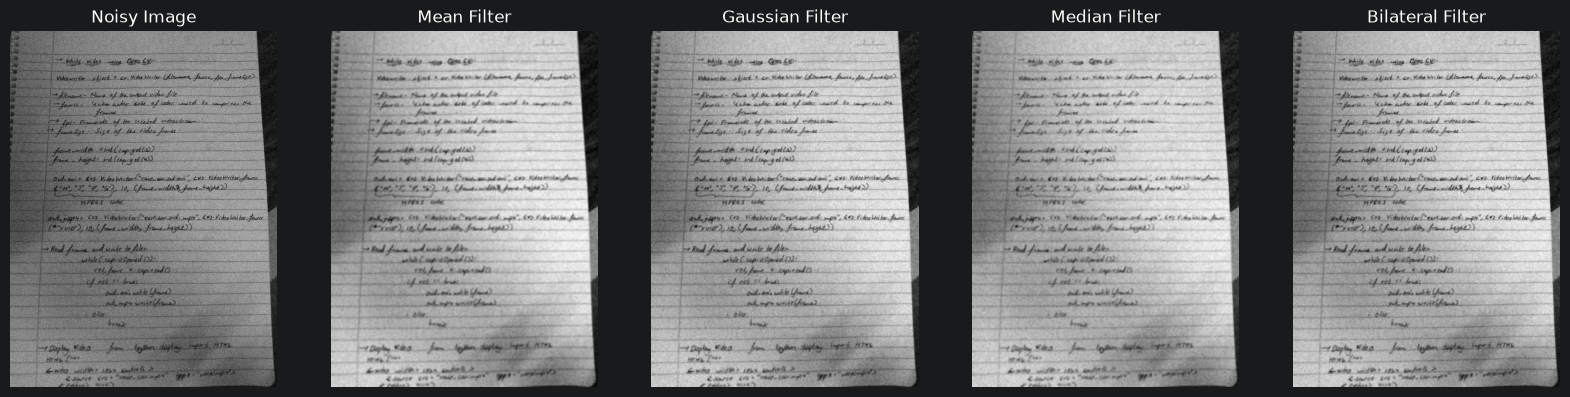

In [14]:

filters = [noisy_img, blur_mean, blur_gaussian, blur_median, blur_bilateral]
titles = ['Noisy Image', 'Mean Filter', 'Gaussian Filter', 'Median Filter', 'Bilateral Filter']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, f, t in zip(axes, filters, titles):
    ax.imshow(f, cmap='gray')
    ax.set_title(t)
    ax.axis('off')
plt.show()